# Step 0: get to know the ShanghaiT2DM data

**Goal:** load our cleaned data, look at it with your own eyes, and check a few numbers against the README. No modelling yet.

**You will learn:** how to load a CSV with pandas, fix a date column, filter and group rows, and make plots with matplotlib. Those are the skills every later step uses.

**How to use this notebook**
1. Run each cell in order with **Shift + Enter**. Read the text above each cell first.
2. Cells marked **Your turn** are small exercises. Try them before looking anything up.
3. If a cell gives an error, read the last line of the error; it usually says what's wrong.

**Files you need** (from the project's `shanghai_t2dm_clean` folder):
`shanghai_t2dm_timeseries.csv`, `shanghai_t2dm_static.csv`, `shanghai_t2dm_recording_qc.csv`
- **Colab:** click the folder icon on the left, then the upload icon, and upload the three files.
- **Kaggle:** create a **Private** dataset with the three files and add it to this notebook (Add data).


In [1]:
# Libraries: pandas = tables, numpy = maths, matplotlib = plots
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
print("pandas", pd.__version__)

pandas 3.0.6


In [2]:
# Find the data files wherever you uploaded them (Colab, Kaggle or your own computer)
def find(name):
    for pattern in [name, f"/content/{name}", f"/kaggle/input/**/{name}", f"**/{name}", f"../data/**/{name}"]:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return hits[0]
    raise FileNotFoundError(f"Could not find {name}. Upload it first (see the instructions above).")

TS_PATH, STATIC_PATH, QC_PATH = (find(f) for f in
    ["shanghai_t2dm_timeseries.csv", "shanghai_t2dm_static.csv", "shanghai_t2dm_recording_qc.csv"])
print(TS_PATH, STATIC_PATH, QC_PATH, sep="\n")

../data\shanghai_t2dm_clean\shanghai_t2dm_timeseries.csv
../data\shanghai_t2dm_clean\shanghai_t2dm_static.csv
../data\shanghai_t2dm_clean\shanghai_t2dm_recording_qc.csv


## 1. Load the three tables

- **timeseries**: one row per 15-minute sensor reading (the *dynamic* stream).
- **static**: one row per recording, with lab results and medical history (the *static*, EHR-like stream).
- **recording_qc**: one row per recording, with quality checks we made during cleaning.

A *recording* is one stretch of about 10–14 days of sensor wear. Most patients have one; 8 patients have two or three.

In [3]:
ts = pd.read_csv(TS_PATH, low_memory=False)
static = pd.read_csv(STATIC_PATH)
qc = pd.read_csv(QC_PATH)

print("timeseries:", ts.shape, "  (rows, columns)")
print("static:    ", static.shape)
print("qc:        ", qc.shape)
ts.head()

timeseries: (112475, 16)   (rows, columns)
static:     (109, 41)
qc:         (109, 22)


,patient_id,recording_id,timestamp,cgm_mgdl,cbg_mgdl,ketone_mmol,diet_en,diet_cn,insulin_sc,oral_agents,csii_bolus_iu,csii_basal_iu_h,insulin_iv,lo70,lo54,hi180
0,2000,2000_0_20201230,2020-12-30 13:54:00,138.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
1,2000,2000_0_20201230,2020-12-30 14:09:00,120.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
2,2000,2000_0_20201230,2020-12-30 14:24:00,106.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
3,2000,2000_0_20201230,2020-12-30 14:39:00,97.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
4,2000,2000_0_20201230,2020-12-30 14:54:00,88.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False


**What the main columns mean**

| Column | Meaning |
|---|---|
| `patient_id` | The person (use this for splitting later, never the row) |
| `recording_id` | One sensor-wear period of that person |
| `timestamp` | When the reading was taken |
| `cgm_mgdl` | Sugar from the skin sensor, in mg/dL |
| `cbg_mgdl` | Finger-prick sugar, only now and then |
| `diet_en` | What was eaten (free text with grams), only at meal times |
| `insulin_sc`, `oral_agents` | Insulin injections and tablets, only when given |
| `lo70`, `lo54`, `hi180` | True/False: is *this* reading below 70, below 54, above 180 |

The full list is in `DATA_README.md`.

## 2. Fix the timestamp column

pandas reads `timestamp` as plain text. We need real dates to do anything with time.

A trap in this dataset: most timestamps look like `2021-05-02 07:28:00`, but 6,250 rows look like `2021-05-02 07:28:00.000`. A strict converter fails on the mix, so we tell pandas to accept mixed formats.

In [4]:
ts["timestamp"] = pd.to_datetime(ts["timestamp"], format="mixed")
print("Unreadable timestamps:", ts["timestamp"].isna().sum())   # should be 0
print("Earliest:", ts["timestamp"].min(), "  Latest:", ts["timestamp"].max())

Unreadable timestamps: 0
Earliest: 2020-09-07 11:23:00   Latest: 2022-01-29 12:18:00


## 3. Look at one patient's day

Plotting a single day teaches you more than any summary number. The dashed lines are the clinical limits we use: below **70** mg/dL is a low, above **180** is a spike. Orange marks are logged meals.

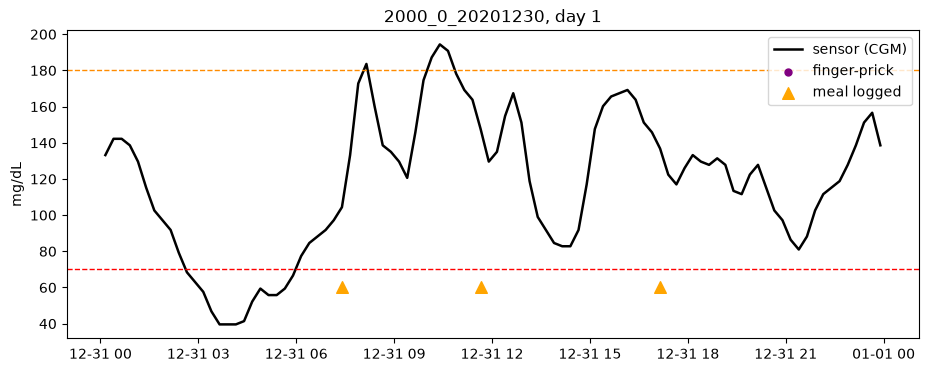

In [5]:
def plot_day(recording_id, day_number=1):
    r = ts[ts["recording_id"] == recording_id].sort_values("timestamp")
    start = r["timestamp"].dt.normalize().min() + pd.Timedelta(days=day_number)
    day = r[(r["timestamp"] >= start) & (r["timestamp"] < start + pd.Timedelta(days=1))]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(day["timestamp"], day["cgm_mgdl"], color="black", lw=1.8, label="sensor (CGM)")
    ax.scatter(day["timestamp"], day["cbg_mgdl"], color="purple", s=25, label="finger-prick", zorder=3)
    meals = day[day["diet_en"].notna()]
    ax.scatter(meals["timestamp"], [60] * len(meals), marker="^", color="orange", s=70, label="meal logged")
    ax.axhline(70, color="red", ls="--", lw=1); ax.axhline(180, color="darkorange", ls="--", lw=1)
    ax.set_ylabel("mg/dL"); ax.set_title(f"{recording_id}, day {day_number}")
    ax.legend(loc="upper right"); plt.show()

plot_day("2000_0_20201230", day_number=1)

**Your turn**
1. Change `day_number` to 2 and 3. Does the pattern repeat each day?
2. Plot recording `"2077_0_20210803"`. Where is the line compared with the purple finger-prick dots? This is why we suspect its sensor is faulty (decision 22).
3. Find a recording with lows: run `qc.sort_values("lo70_episodes", ascending=False).head()` and plot one of them.

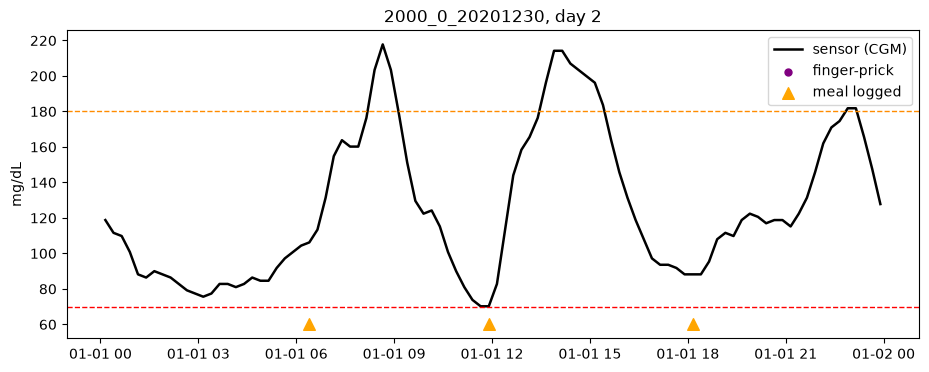

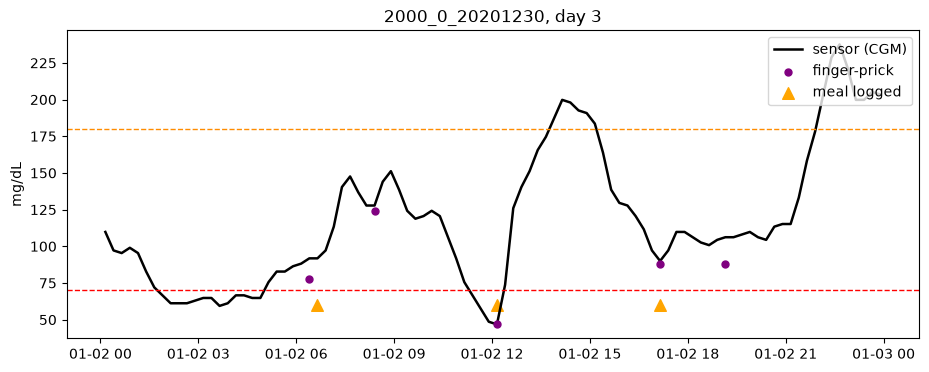

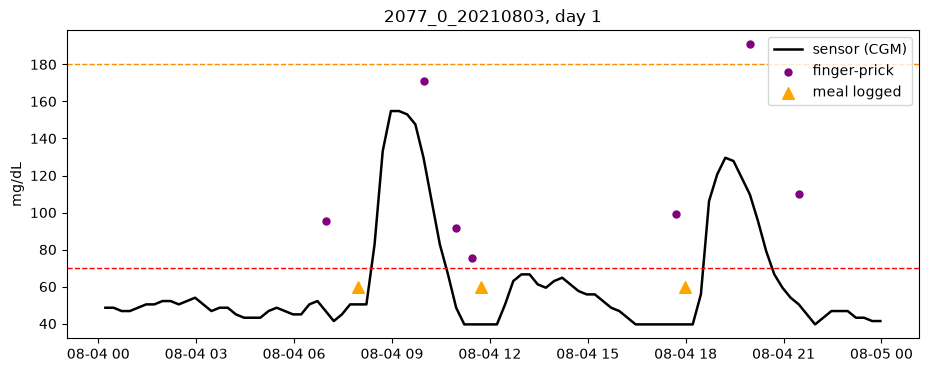

,recording_id,patient_id,rows,cgm_missing,start,end,days,gaps_over_30min,dup_timestamps,bad_timestamps,median_cgm,pct_lo70,pct_hi180,meals_logged,insulin_sc_doses,oral_agent_entries,cbg_pairs,cgm_minus_cbg_mean,lo70_episodes,lo54_episodes,hi180_episodes,qc_flag
85,2077_0_20210803,2077,1023,0,2021-08-03 15:58:00,2021-08-14 07:28:00,10.65,0,0,0,55.8,67.25,0.20,33,0,22,33,-47.0,28,36,1,suspect
71,2066_0_20210615,2066,1220,0,2021-06-15 14:50:00,2021-06-28 07:35:00,12.70,0,0,0,97.2,13.36,0.33,39,0,14,30,-25.0,20,6,1,ok
94,2085_0_20200907,2085,1339,0,2020-09-07 11:23:00,2020-09-21 09:53:00,13.94,0,0,0,84.6,6.12,0.00,53,0,0,0,NaN,19,2,0,ok
103,2094_0_20211109,2094,1338,0,2020-11-09 11:22:00,2020-11-23 09:37:00,13.93,0,0,0,151.2,5.75,30.04,45,40,25,13,10.4,18,1,22,ok
83,2075_0_20210720,2075,938,0,2021-07-20 14:43:00,2021-07-30 08:58:00,9.76,0,0,0,93.6,23.13,0.21,33,0,31,10,-47.3,17,4,1,ok


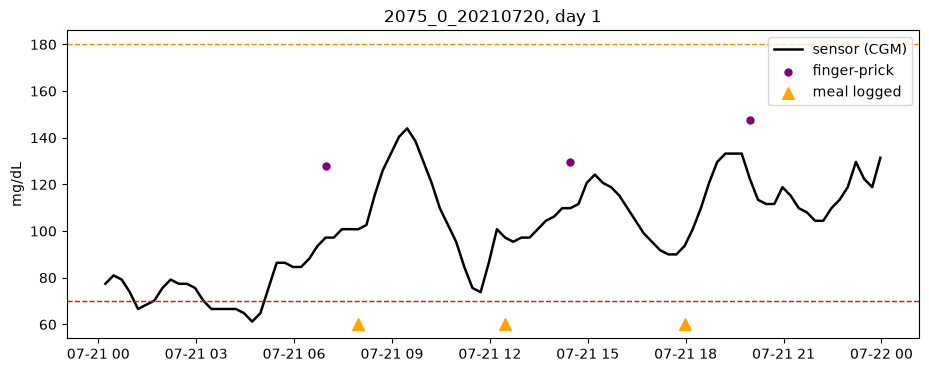

In [6]:
# Your turn: section 3
plot_day("2000_0_20201230", day_number=2)
plot_day("2000_0_20201230", day_number=3)
plot_day("2077_0_20210803", day_number=1)
display(qc.sort_values("lo70_episodes", ascending=False).head())
plot_day("2075_0_20210720", day_number=1)

**My answers: section 3**
1. Sugar rises after each logged meal and comes back down on every day. What changes is how many lows there are and how high the peaks go.
2. In 2077 the sensor line sits below the purple finger-prick dots (about 47 mg/dL lower on average), so the sensor reads too low and is probably faulty.
3. In 2075 the lows happen on the second calendar day, mostly between 03:00 and 06:00 (night). Day 1 of a recording has about 2 to 3 times the low rate of later days (sensor settling), so some day-1 lows may not be real.

## 4. Count low episodes and check them against the README

A **low episode** = 2 or more readings in a row below 70 mg/dL (decision 21). One reading alone can be sensor noise.

How the code finds them: mark each reading True/False for "below 70", give a new group number every time the value flips, then count groups that are True and at least 2 readings long. We count **per recording**, so the end of one recording never joins onto the start of the next.

The README says there are **367** low episodes in total. If we get 367, our understanding matches the cleaning.

In [7]:
def count_episodes(sugar, threshold=70, below=True):
    flag = sugar < threshold if below else sugar > threshold
    group = (flag != flag.shift()).cumsum()          # new number each time the flag flips
    runs = flag.groupby(group).agg(["first", "size"])  # each run: is it True? how long?
    return int((runs["first"] & (runs["size"] >= 2)).sum())

valid = ts.dropna(subset=["cgm_mgdl"]).sort_values(["recording_id", "timestamp"])
lows_per_recording = valid.groupby("recording_id")["cgm_mgdl"].apply(count_episodes)

print("Total low episodes:", lows_per_recording.sum(), "(README says 367)")

Total low episodes: 367 (README says 367)


Patients with no lows at all: 39 of 100


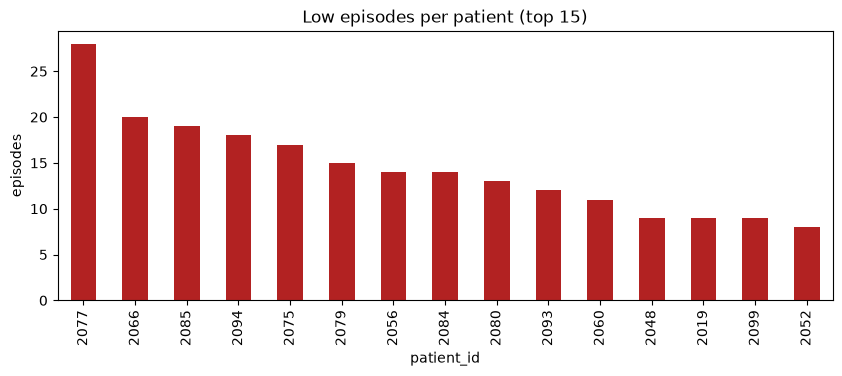

In [8]:
lows_per_patient = lows_per_recording.groupby(lambda rid: int(rid[:4])).sum().sort_values(ascending=False)
print("Patients with no lows at all:", (lows_per_patient == 0).sum(), "of", len(lows_per_patient))

lows_per_patient.head(15).plot(kind="bar", figsize=(10, 3.5), color="firebrick")
plt.title("Low episodes per patient (top 15)"); plt.ylabel("episodes"); plt.xlabel("patient_id"); plt.show()

**What to notice:** lows are very unevenly spread. 39 patients have none; a handful have most of them. This is why we will score the model **per patient**, not only as one overall number.

**Your turn**
1. Count **spikes** (above 180) with `count_episodes(..., threshold=180, below=False)`. The README says 1,807.
2. Count **severe lows** (below 54). The README says 100.

In [9]:
# Your turn: write your code here
valid = ts.dropna(subset=["cgm_mgdl"]).sort_values(["recording_id", "timestamp"])

high_per_recording = valid.groupby("recording_id")["cgm_mgdl"].apply(
    lambda s: count_episodes(s, threshold=180, below=False))
print("Total spikes:", high_per_recording.sum(), "(README says 1807)")

# severe lows (README says 100)
severe_per_recording = valid.groupby("recording_id")["cgm_mgdl"].apply(
    lambda s: count_episodes(s, threshold=54, below=True))
print("Total severe lows:", severe_per_recording.sum(), "(README says 100)")



Total spikes: 1807 (README says 1807)
Total severe lows: 100 (README says 100)


**My answers: section 4**
1. Yes: 1,807 spikes.
2. Yes: 100 severe lows.

## 5. What happens to sugar after a meal?

For every logged meal we take the sensor readings from 1 hour before to 3 hours after, line them up so that time 0 = the meal, and average them. This shape (rise, peak, fall) is what our spike model will try to predict.

We use readings by position (each row is about 15 minutes apart) and skip any meal where the window has a gap.

Meals used: 3685


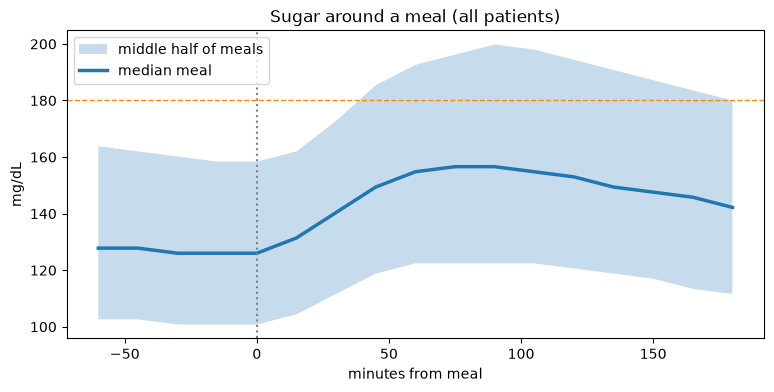

In [10]:
before, after = 4, 12                        # 4 readings before (1 h), 12 after (3 h)
curves = []
for rid, r in ts.sort_values("timestamp").groupby("recording_id"):
    r = r.reset_index(drop=True)
    for i in r.index[r["diet_en"].notna()]:
        if i - before < 0 or i + after >= len(r):
            continue
        window = r.loc[i - before:i + after]
        steps = window["timestamp"].diff().dt.total_seconds().div(60).iloc[1:]
        if steps.between(13, 17).all() and window["cgm_mgdl"].notna().all():
            curves.append(window["cgm_mgdl"].to_numpy())

curves = np.array(curves)
minutes = np.arange(-before, after + 1) * 15
print("Meals used:", len(curves))

plt.figure(figsize=(9, 4))
plt.fill_between(minutes, np.percentile(curves, 25, axis=0), np.percentile(curves, 75, axis=0),
                 alpha=0.25, label="middle half of meals")
plt.plot(minutes, np.median(curves, axis=0), lw=2.5, label="median meal")
plt.axvline(0, color="grey", ls=":"); plt.axhline(180, color="darkorange", ls="--", lw=1)
plt.xlabel("minutes from meal"); plt.ylabel("mg/dL"); plt.title("Sugar around a meal (all patients)")
plt.legend(); plt.show()

**Your turn**
1. Around how many minutes after a meal is the median peak?
2. Look at the shaded band: how different are meals from each other? That spread is what makes prediction hard.

In [11]:
# Your turn: section 5
median_curve = np.median(curves, axis=0)
peak_min = minutes[np.argmax(median_curve)]
q25, q75 = np.percentile(curves, 25, axis=0), np.percentile(curves, 75, axis=0)
i = np.argmax(median_curve)
print("Median peak at", peak_min, "minutes after the meal, about", round(median_curve[i]), "mg/dL")
print("Middle half of meals at that time:", round(q25[i]), "to", round(q75[i]), "mg/dL")

Median peak at 75 minutes after the meal, about 157 mg/dL
Middle half of meals at that time: 122 to 196 mg/dL


**My answers: section 5**
1. The median curve is flat at its top, about 157 mg/dL, from 75 to 90 minutes after the meal. The code reports 75 (the first of the two equal readings), so say "75 to 90 minutes".
2. The shaded band is wide: at the peak the middle half of meals ranges from about 122 to 196 mg/dL, so the meal alone cannot predict a spike. The model also needs other inputs (dose timing, the patient's own history, time of day).

## 6. Join the static facts: who has the most lows?

Here the two streams meet for the first time. We join the low counts (from the time series) onto the static table (from the medical records) using `recording_id`. Joining like this is the core of "fusing" the two streams that the challenge asks for.

Medical expectation: lows are mostly caused by insulin and by sulfonylurea tablets (FROM MEMORY; worth checking). So patients on those drugs *should* have more lows. Let's see.

In [12]:
per_rec = qc[["recording_id", "days", "cgm_minus_cbg_mean", "cbg_pairs"]].merge( lows_per_recording.rename("low_episodes").reset_index(), on="recording_id")
per_rec = per_rec.merge(static[["recording_id", "on_insulin", "on_sulfonylurea", "Hypoglycemic Agents"]], on="recording_id")
per_rec["lows_per_week"] = per_rec["low_episodes"] / per_rec["days"] * 7

print(per_rec.groupby("on_insulin")["lows_per_week"].agg(["count", "mean", "median"]).round(2))

            count  mean  median
on_insulin                     
False          53  3.07    1.06
True           56  1.39    0.25


**Surprised?** Patients *not* on insulin have more lows here. Before believing a surprising result, investigate it. Let's look at the recordings with the most lows, their medicines, and how far their sensor reads from the finger-prick tests (`cgm_minus_cbg_mean`: negative means the sensor reads lower than the finger-prick; across all recordings it is typically about -13 mg/dL).

In [13]:
cols = ["recording_id", "Hypoglycemic Agents", "lows_per_week", "cbg_pairs", "cgm_minus_cbg_mean"]
per_rec.sort_values("lows_per_week", ascending=False)[cols].head(10).round(1)

,recording_id,Hypoglycemic Agents,lows_per_week,cbg_pairs,cgm_minus_cbg_mean
85,2077_0_20210803,"sitagliptin, metformin",18.4,33,-47.0
61,2056_0_20210524,none,16.6,12,-27.6
93,2084_0_20211013,gliquidone,14.2,6,-35.4
83,2075_0_20210720,metformin,12.2,10,-47.3
71,2066_0_20210615,gliclazide,11.0,30,-25.0
94,2085_0_20200907,none,9.5,0,NaN
103,2094_0_20211109,"insulin glargine, Humulin R, voglibose",9.0,13,10.4
23,2019_0_20210513,insulin aspart 70/30,8.1,53,-4.5
88,2079_0_20210809,metformin,7.6,0,NaN
89,2080_0_20210816,gliclazide,6.6,9,-24.2


**Your turn: be the detective**
1. How many of the top 10 are on insulin or a sulfonylurea (gliclazide, gliquidone, glimepiride...)?
2. For the others, look at `cgm_minus_cbg_mean`. Is their sensor reading close to the finger-prick, or far below it?
3. In one sentence: what could make a patient on no low-causing drugs show many "lows" on the sensor?

**Lesson:** a correlation in the data can come from the *measurement*, not the body. This affects which "lows" we let the model learn from (decision 22). Write down your answer and send it to Claude.

In [14]:
# Your turn: section 6
top = per_rec.sort_values("lows_per_week", ascending=False).head(10).copy()
top["low_causing_drug"] = top["on_insulin"] | top["on_sulfonylurea"]
print("Top 10 on insulin or a sulfonylurea:", int(top["low_causing_drug"].sum()), "of 10")
print("Typical (median) sensor minus finger-prick, all recordings:", round(qc["cgm_minus_cbg_mean"].median(), 1))
top[~top["low_causing_drug"]][["recording_id", "Hypoglycemic Agents", "lows_per_week", "cbg_pairs", "cgm_minus_cbg_mean"]].round(1)

Top 10 on insulin or a sulfonylurea: 5 of 10
Typical (median) sensor minus finger-prick, all recordings: -13.0


,recording_id,Hypoglycemic Agents,lows_per_week,cbg_pairs,cgm_minus_cbg_mean
85,2077_0_20210803,"sitagliptin, metformin",18.4,33,-47.0
61,2056_0_20210524,none,16.6,12,-27.6
83,2075_0_20210720,metformin,12.2,10,-47.3
94,2085_0_20200907,none,9.5,0,NaN
88,2079_0_20210809,metformin,7.6,0,NaN


**My answers: section 6**
1. 5 of the top 10 are on insulin or a sulfonylurea (2084, 2066, 2094, 2019, 2080).
2. Of the other 5: 2077 and 2075 read about 47 mg/dL below the finger-pricks (far below the typical -13), 2056 about 28 below, and 2085 and 2079 have no finger-pricks (NaN), so their sensors cannot be checked.
3. A sensor that reads too low (or is still settling on day 1) can show "lows" that are not real; diet or naturally low sugar are possible but cannot be confirmed without finger-pricks.

**Note:** the numbers 94, 88, 85 and 83 on the left of the table are row numbers, not recording ids. They are recordings 2085, 2079, 2077 and 2075.

**Terms:** CGM = continuous glucose monitor (the sensor); CBG = capillary blood glucose (the finger-prick); NaN = no finger-prick tests to compare with.

## Done? Your step-0 checklist

- [x] All cells run without errors
- [x] Total low episodes = 367, spikes = 1,807, severe lows = 100
- [x] You looked at recording 2077 and can say in one sentence what looks wrong
- [ ] You can explain in your own words: recording vs patient, feature vs label, why we count lows per recording

**Send back to Claude:** your answers to the "Your turn" questions and anything that surprised you. That feeds step 2 (labels).

**Save your work:** Colab: File → Save a copy in Drive. Kaggle: Save Version. Later, the finished code moves into the repo folder `ml/` (decision 31).